# Transformers for NLP + Chatbots

Similar to RNNs.. but without the R. No recurrent or conv layers in the OG transformer. +New multi-head attention (MHA). No recurrence = more stable gradients, faster training, parallelizable.

Transformers also got good at audio, visual. Chunking images and sending them to the transformer as a replacement for tokens. Text+image = multimodal.

## The Original Transformer: Attention Is All You Need

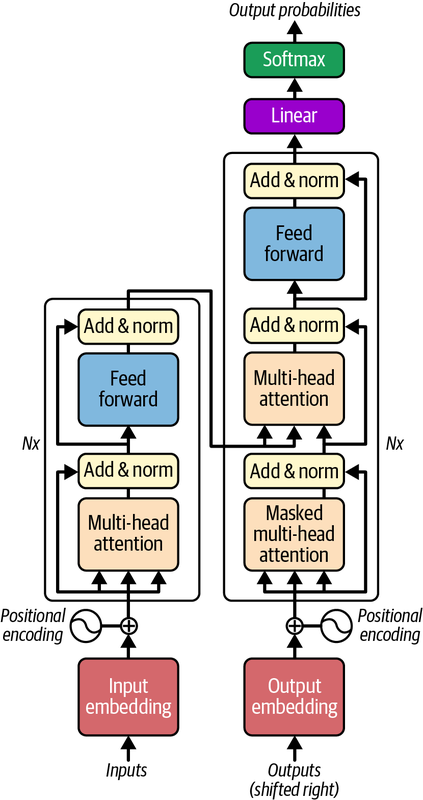

Encoder: transform the inputs such that each token representation perfectly represents its meaning/context. Besides embed layer, each layer takes in [batch size, max_input_seq_len, embed_size] and returns the exact same shape. Token representations get "transformed" across layers. 

Decoder: take encoder outputs + current progress on translation/whatever task, and predict next token. The decoder's purpose is to transform each representation from the encoder into a representation that will be used to predict the next token. Every encoder layer takes [batch size, max output seq len, embedding size] and returns same shape tensor (besides embedding and output layers). 

The final linear layer will hopefully have a high output for the correct token (or similar ones - synonyms) and low output for the wrong ones. Output shape is [batch size, max output seq len, vocab size]. 

The model has softmax, but we dont use it in pytorch, we train w/ cross entropy loss (uses logits not probas). 

- Note: skip connections. For the encoder, each step is getting some version of the non-transformed inputs. For the decoder,e ach step is getting some version of the non-transformed encoder output.
- Layer Norm after each attention block
- Feedforward modules have 2 dense layers, first one uses ReLU, second one has no activation
- Every layer treats tokens independently -> so how to learn?
    - Encoder MHA updates token representations by attending to every single token in its input. *Self attenton*. 
    - Decoder Masked MHA does the same thing, but causally. Only looks at current and past tokens. 
    - Decoder upper MHA layer pays attention to representations from the encoder stack, this is *cross attention*.
        - So when the next output token is "futbol", pays more attention to "soccer"
    - Positional encoding: dense vectors that represent each token's position in a sentence. n'th position encoding gets added to n'th token embedding. This is CRUCIAL: attention doesn't care about token position.

### Positional Encodings

A positional encoding is some dense vector that encodes the position of a token. Implement this with embeddings / nn.Parameter (parameter is faster)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PositionalEmbedding(nn.Module):
    def __init__(self, max_length, embed_dim, dropout=0.1):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(max_length, embed_dim)*.02) # small random weight init
        self.dropout = nn.Dropout(dropout) # to prevent overfit

    def forward(self, X):
        return self.dropout(X + self.pos_embed[:X.size(1)]) 

#### Relative Positional Encodings
Issue: Model doesn't see long input sequences as often as short ones, so it struggles with longer context. Also, harder to find context in bigger documents than smaller ones.

Solution: Relative Positional Encoding. Now, you dont care about absolute position, you care about the position of a token relative to other tokens. Now whether a token is at 10k or 10 it sees another token 5 units away the same. Helps with long sequence extrapolation. Also, locality bias! Which is helpful, and we humans have it. Model sees more pairs of +-1 distance than +-1000 distance.

**Relative Position Encodings (RPE)**

The original 2018 method. Adds trainable rpe's to k-v tokens when computing scaled dot product attention. 

This method caps the max distance: if tokens are more than 128 apart, set their relative distance to 128 (or whatever you want). 

Now, add trainable embedding matrices $A^K$ and $A^V$ to each MHA layer. In both matrices, each row is an embedding that represents some possible relative distance. I.e at (0,0) its 0, (0,1) its 1, etc. Dimensionality of each embedding is d (with subscript for whatever matrix, but usually both k and v have same embedding dim). 

When computing attention score $e_{i,j}$ for i'th query token q and j'th key k, embedding for relative position i-j is added to the key token. RPE computes: $q_i \cdot (k_j+a_{i-j}) / \sqrt{d_k}$. Basically like a bias term for the key. 

Then, when computing output o for i'th query token, you add a relative pos embed to each value vector, which comes from $A^V$. 
    $o_i = \sum_{j=1}^{L_K} \alpha_{i,j}(v_j+a^V_{i-j})$

The authors notes that the second embedding didn't really help, and future pos encodings dropped it.

In 2019, Google came out with a new method that just added a single learnable bias scalar to each attn score, based on rel position. Much simpler and performed better.

Biased based RPE in torch:

In [ ]:
class MultiheadAttentionWithBiasRPE(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1, r_max=128): # r max = maximum relative distance allowed
        # the rest of the constructor is unchanged
        self.biases = nn.Parameter(torch.zeros(num_heads, 2 * r_max - 1)) 
        # the rest of the class is unchanged for now

In [ ]:
# then you need a method that takes length of query and key, and makes tensor of h, Lq, Lk, which has bias for each qk position pair
# h is the attn head number - note [0, 1, 10]=[0, 0, 9], but [1, 1, 10]!=[0, 0, 9]. Diff biases per head.
def gather_biases(self, Lq, Lk):
    h, n_biases = self.biases.shape  # [h, 2 * r_max - 1]
    r_max = (n_biases + 1) // 2
    pos_q = torch.arange(Lq, device=self.biases.device)  # [0, ..., Lq - 1] all query pos
    pos_k = torch.arange(Lk, device=self.biases.device)  # [0, ..., Lk - 1] all key pos
    rel_pos = pos_q[:, None] - pos_k[None, :]  # [Lq, Lk] (contains i - j) LxL matrix containing all rel pos's
    rel_pos = rel_pos.clamp(-r_max + 1, r_max - 1) + r_max - 1  # [Lq, Lk] set max dist, and reindex since no negative indices in bias table
    return self.biases[:, rel_pos]  # [h, Lq, Lk]

In [ ]:
def forward(self, query, key, value):
    # the rest is unchanged
    scores = q @ k.transpose(2, 3) / self.d**0.5  # (B, h, Lq, Lk)
    b = self.gather_biases(query.size(-2), key.size(-2))  # (h, Lq, Lk)
    scores = scores + b
    # the rest is unchanged

**Rotary Position Embeddings (RoPE)**

Just rotate each query and key token by an angle proportional to absolute position.

(pretending token representations are 2D) Pretend query is at 19, key is at 5. 

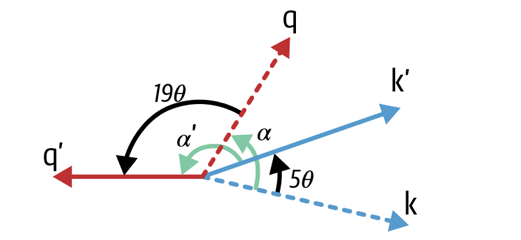

The relative distance r=i-j becomes $\alpha' = \alpha + r\theta$,  the relative position info is encoded in the distance after rotation

How does this work? Attn computes dot product $q' \cdot k' = cos(\alpha') \times ||q'|| \times ||k'||$. Rotation does not change vector length, so the magnitudes are the same as the original, so actually $q' \cdot k' = cos(\alpha + r\theta) \times ||q|| \times ||k||$

But this trick only works in 2D :(. So, RoPE groups token dims into pairs, makes 2D subspaces, and rotates each subspace, using a new theta for each space. OG authors proposed $\theta_k = B^{-2k/d}$, where B is some constant and d is token dimensionality. Now theta k is smaller as k increases, so first subspaces get more rotations per poss than last subspaces. 

In [ ]:
# This block precomputes all cosines/sines for angles p thetak for all pairs of absolute position p and subspace k
def precompute_rope_cos_sin(d, max_len, base=10_000):
    theta = base ** (-torch.arange(0, d, 2).float() / d)  # θₖ, shape: [d // 2]
    positions = torch.arange(max_len)  # p, shape: [max_len]
    freqs = torch.outer(positions, theta)  # p * θₖ, shape: [max_len, d // 2]
    freqs_twice = freqs.repeat_interleave(2, dim=-1)  # shape: [max_len, d]
    return freqs_twice.cos(), freqs_twice.sin()  # shape: both [max_len, d]
d, max_len = 64, 4_096
cos_theta, sin_theta = precompute_rope_cos_sin(d, max_len)

I cannot explain how the 2d rotation works better than Geron:

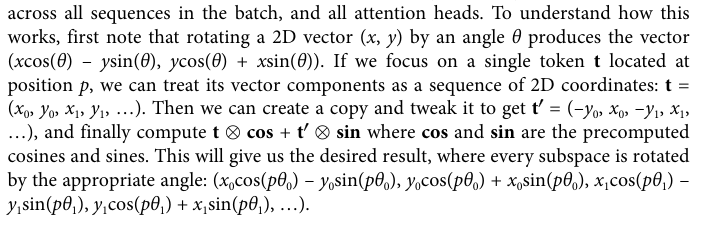

In [9]:
# this function applies RoPE to a tensor
# Rotate all 2d subspaces simulataneously for all tokens in the tensor, across all sequences and attn heads
def rope_rotation(t, cos_theta, sin_theta):
    t_grouped = t.reshape(*t.shape[:-1], -1, 2)  # group pairs of dims
    t_swapped = t_grouped[..., [1, 0]]  # swap 2D axes: (x, y) -> (y, x)
    t_swapped[..., 0] *= -1  # for each pair, (y, x) -> (–y, x)
    t_rotated_half = t_swapped.flatten(start_dim=-2)  # [-y0, x0, -y1, x1,...]
    L = t.size(-2)
    return t * cos_theta[:L] + t_rotated_half * sin_theta[:L]  # same shape as t

batch_size, n_heads, Lq, Lk, d = 32, 8, 800, 800, 64
Q = torch.randn(batch_size, n_heads, Lq, d)
K = torch.randn(batch_size, n_heads, Lk, d)
Q_rope = rope_rotation(Q, cos_theta, sin_theta)
K_rope = rope_rotation(K, cos_theta, sin_theta)

One of the best rope variants: YaRN. Messes with base B, scaling it by some factor lambda, to do interpolation. YaRN adds position interpolation and scaling attn score. This helps a lot for sequences that go beyond the maximum sequence length.

| Method | Attention Score $e_{i,j}$ | Output $o_i$ |
|--------|--------------------------|--------------|
| Regular | $\dfrac{q_i \cdot k_j}{\sqrt{d_k}}$ | $\sum_{j=1}^{L_k} \alpha_{i,j} v_j$ |
| RPE (full) | $\dfrac{q_i \cdot k_j}{\sqrt{d_k}} + a^K_{i-j}$ | $\sum_{j=1}^{L_k} \alpha_{i,j} v_j + a^V_{i-j}$ |
| RPE (bias) | $\dfrac{q_i \cdot k_j}{\sqrt{d_k}} + b_{j-i}$ | $\sum_{j=1}^{L_k} \alpha_{i,j} v_j$ |
| RoPE | $\dfrac{R^i_\theta q_i \cdot R^j_\theta k_j}{\sqrt{d_k}}$ | $\sum_{j=1}^{L_k} \alpha_{i,j} v_j$ |
| ALiBi | $\dfrac{q_i \cdot k_j}{\sqrt{d_k}} + m_a \cdot (i - j)$ | $\sum_{j=1}^{L_k} \alpha_{i,j} v_j$ |

### Multi Head Attention (MHA)